# Kaggle Housing Price Prediction
Notebook for the *Housing Prices Competition for Kaggle Learn Users*

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

## Load Data and Perform First Round of Filtering

In [105]:
# Load the Kaggle dataset
path_train = './input/train.csv.gz'
path_test  = './input/test.csv.gz'

train_full = pd.read_csv(path_train, compression='gzip')
test_full  = pd.read_csv(path_test, compression='gzip')

print(f'Shape of train_full dataset: {train_full.shape}')
print(f'Shape of test_full dataset: {test_full.shape}')

Shape of train_full dataset: (1460, 81)
Shape of test_full dataset: (1459, 80)


In [106]:
# remove rows with missing target (SalePrice)
print(f'{train_full["SalePrice"].isna().sum()} rows have a missing SalePrice')
train = train_full.dropna(subset=['SalePrice']) # no missing SalePrice so not needed

# remove any duplicate training rows
print(f'{train.duplicated().sum()} trainig rows are duplicates')
train = train.drop_duplicates(keep='first') # no duplicates so not needed

0 rows have a missing SalePrice
0 trainig rows are duplicates


In [107]:
# look for columns with a lot of missing data
missing_count = train.isnull().sum().sort_values(ascending=False)
missing_pct   = ((train.isnull().sum() / train.isnull().count()).sort_values(ascending=False) * 100).astype(int)
missing_data  = pd.concat([missing_count, missing_pct], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,99
MiscFeature,1406,96
Alley,1369,93
Fence,1179,80
MasVnrType,872,59
FireplaceQu,690,47
LotFrontage,259,17
GarageQual,81,5
GarageFinish,81,5
GarageType,81,5


In [121]:
# some columns here are nan for no feature so we can encode that instead of keeping values nan
train['PoolQC']        = train['PoolQC'].fillna('NA')
train['MiscFeature']   = train['MiscFeature'].fillna('NA')
train['Alley']         = train['Alley'].fillna('NA')
train['Fence']         = train['Fence'].fillna('NA')
train['MasVnrType']    = train['MasVnrType'].fillna('NA')
train['FireplaceQu']   = train['FireplaceQu'].fillna('NA')
train['GarageQual']    = train['GarageQual'].fillna('NA')
train['GarageFinish']  = train['GarageFinish'].fillna('NA')
train['GarageType']    = train['GarageType'].fillna('NA')
train['GarageCond']    = train['GarageCond'].fillna('NA')
train['BsmtFinType2']  = train['BsmtFinType2'].fillna('NA')
train['BsmtExposure']  = train['BsmtExposure'].fillna('NA')
train['BsmtCond']      = train['BsmtCond'].fillna('NA')
train['BsmtQual']      = train['BsmtQual'].fillna('NA')
train['BsmtFinType1']  = train['BsmtFinType1'].fillna('NA')

# other columns are nan but can be encoded as 0 rather than keeping them nan
train['LotFrontage'] = train['LotFrontage'].fillna(0)

# some I'm not sure how to encode yet...
# revist these later if they are needed...
# train['GarageYrBlt'].describe()
# train['MasVnrArea'].describe()

# no definition for nan in Electrical so we can delete the row with the nan
train = train.drop(train.loc[train['Electrical'].isnull()].index)

# check if nan values remain
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')


# alternatively can consider dropping columns that are missing a significant amount of data
# but can also examine data first and decide to delete later
# train = train.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'])

Remaining NaN values:
GarageYrBlt    81
MasVnrArea      8
MSZoning        0
MSSubClass      0
LotArea         0
dtype: int64


## Investigate Correlations Between Numeric Columns

In [122]:
def plot_scatter(df, x_col, y_col):
    '''
    Create a quick scatter plot between
    two columns in a dataframe
    '''
    data = pd.concat([df[x_col], df[y_col]], axis=1)
    
    data.plot.scatter(x=x_col, y=y_col)
    plt.show()

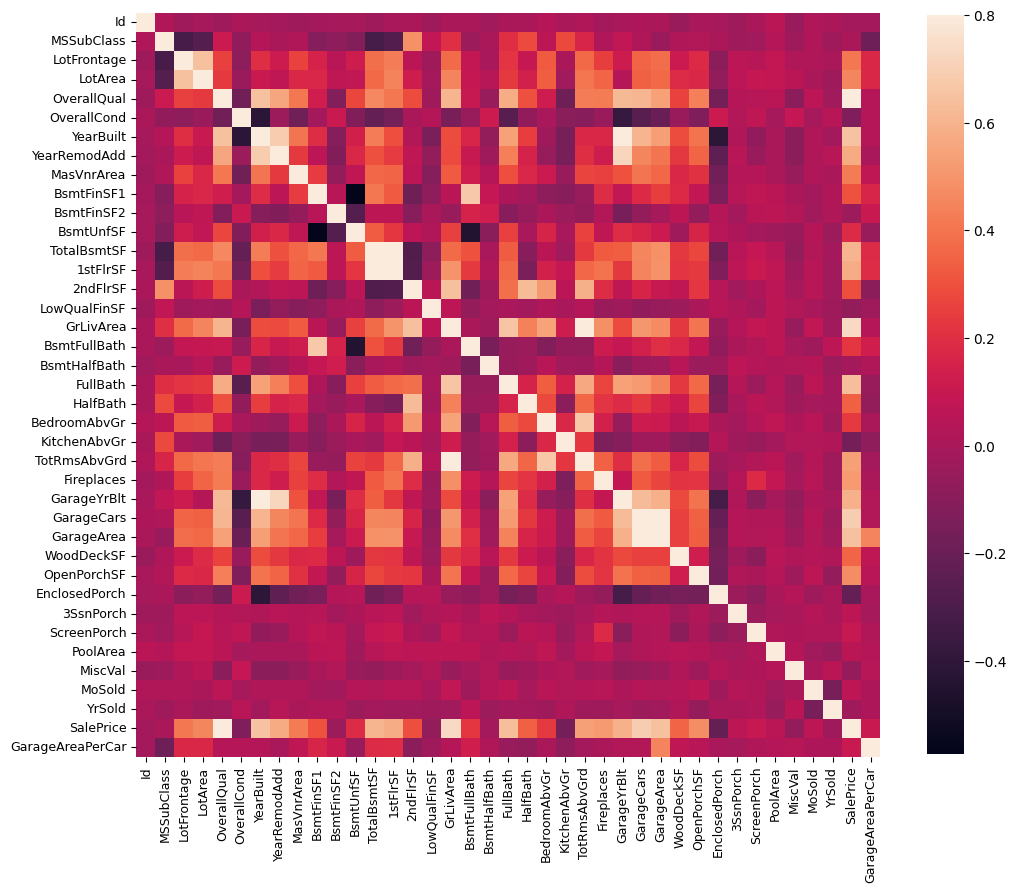

In [104]:
correlation_matrix = train.corr(method='spearman', numeric_only=True) # spearman to account for potential non-linearity

fig, ax = plt.subplots(figsize=(12,12))
sns.heatmap(correlation_matrix, vmax=0.8, square=True, cbar_kws={'shrink': 0.8})

ax.tick_params(axis='both', labelsize=9)
plt.show()

In [81]:
# look at largest correlations between columns
n = 15

mask           = np.tril(np.ones(correlation_matrix.shape), k=-1).astype(bool)
lower_triangle = correlation_matrix.where(mask)

most_correlated_columns = (lower_triangle.unstack().abs().nlargest(n).dropna())

print('Columns with highest Spearman correlation:')
most_correlated_columns

Columns with highest Spearman correlation:


YearBuilt     GarageYrBlt     0.890546
GarageCars    GarageArea      0.853317
TotalBsmtSF   1stFlrSF        0.829292
GrLivArea     TotRmsAbvGrd    0.827874
OverallQual   SalePrice       0.809829
GrLivArea     SalePrice       0.731310
YearRemodAdd  GarageYrBlt     0.722377
GarageCars    SalePrice       0.690711
YearBuilt     YearRemodAdd    0.684388
BsmtFinSF1    BsmtFullBath    0.674175
BedroomAbvGr  TotRmsAbvGrd    0.667822
GrLivArea     FullBath        0.658419
YearBuilt     SalePrice       0.652682
LotFrontage   LotArea         0.649633
GarageArea    SalePrice       0.649379
dtype: float64

In [100]:
# GarageCars and GarageArea essentially represent the same thing
# so we can combine them
train['GarageAreaPerCar'] = train['GarageArea'] / train['GarageCars']
train['GarageAreaPerCar'] = train['GarageAreaPerCar'].fillna(0)
train['GarageAreaPerCar'].describe()

count    1460.000000
mean      256.935274
std        87.957630
min         0.000000
25%       225.333333
50%       263.500000
75%       290.000000
max       924.000000
Name: GarageAreaPerCar, dtype: float64

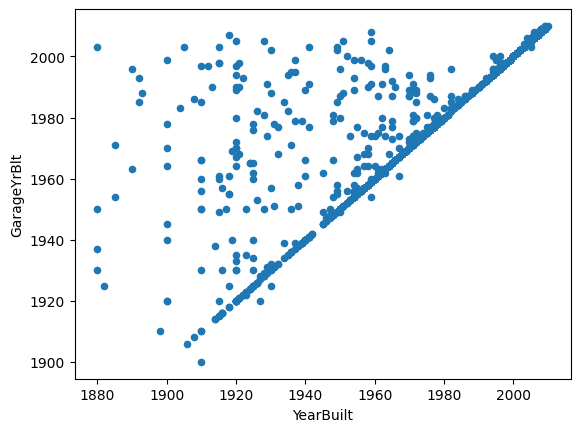

In [ ]:
# YearBuilt vs GarageYrBlt
x = 'YearBuilt'
y = 'GarageYrBlt'

data = pd.concat([train[x], train[y]], axis=1)
data.plot.scatter(x=x, y=y)
plt.show()

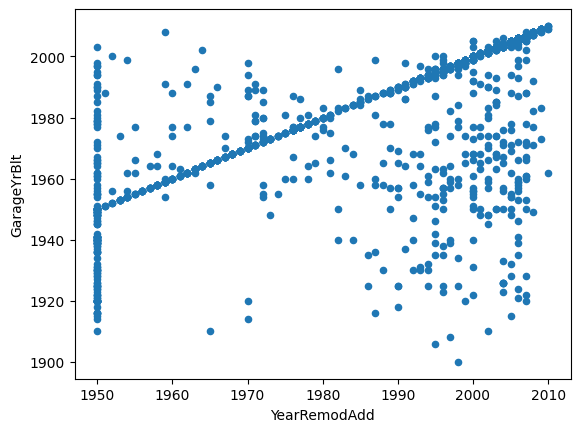

In [86]:
# YearBuilt vs GarageYrBlt
x = 'YearRemodAdd'
y = 'GarageYrBlt'

data = pd.concat([train[x], train[y]], axis=1)
data.plot.scatter(x=x, y=y)
plt.show()

In [ ]:
# We can combine all the bathroom columns into one combined total bathrooms number
# to remove seemingly redundant columns
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

## Deal with Outliers
Don't want to train on a few special cases but rather want to focus on the bulk of the data

## Encode Categorical Columns

## Normalize SalePrice
Do this to avoid skewing the variance that the decision trees are trying to minimize when splitting

# OLD Solution
\
\
\
Spacer

## Start with a simple approach only considering numeric data columns with no missing values
This is the first goal in the Kaggle Intro to Machine Learning course. Further courses will discuss how to address the other data columns so I'll just start with this subset for now. We can first examine all the numeric features available in the dataset to identify which might be good predictors by looking at correlation with SalePrice and feature importances when all data columns are used in a random foret model.

In [2]:
# Load the Kaggle training dataset
path_house_data = './input/train.csv.gz'
house_data      = pd.read_csv(path_house_data, compression='gzip')

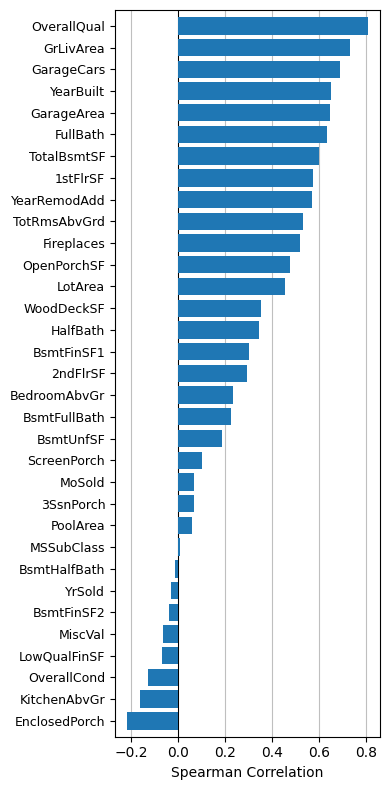

In [3]:
# To get a first estimate of which features might be important we can just
# look at which of the numeric features correlate with sale price.
# Note: use spearman correlation to catch any monotonic relationships
#       that might be nonlinear
correlations = house_data.dropna(axis=1).corr(numeric_only=True, method='spearman')['SalePrice'].sort_values().drop(['SalePrice', 'Id'])
all_columns  = correlations.index.to_list()

fig, ax = plt.subplots(figsize=(4,8))

ax.barh(correlations.index, correlations.values, zorder=10)
ax.axvline(0, color='k', linewidth=0.75, linestyle='-')
ax.tick_params(axis='y', labelsize=9)
ax.set_xlabel('Spearman Correlation')
ax.margins(y=0.01)
ax.grid(axis='x', color='k', alpha=0.25)

fig.tight_layout()
plt.show()

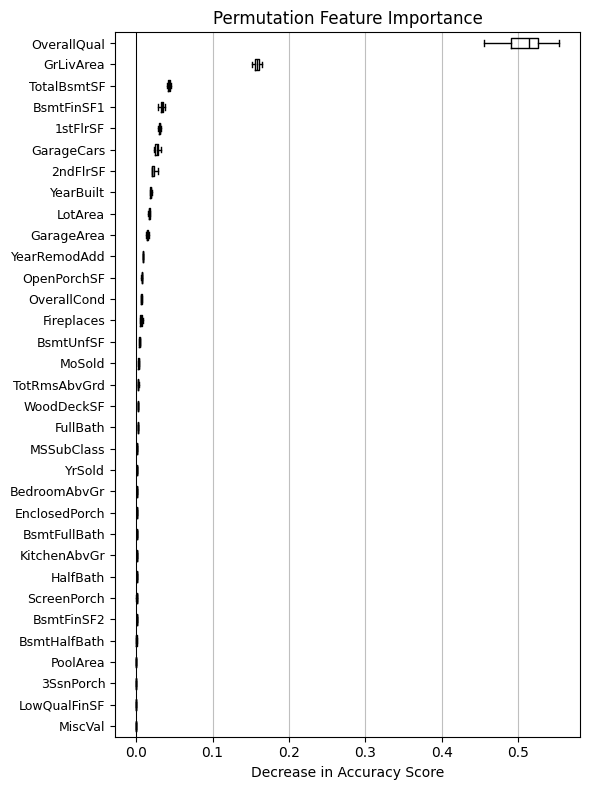

In [4]:
# Alternatively, to identify important features we can train a random
# forest on all these columns and plot the feature importances
# Note: use permutation importance to reduce bias to high-cardinality features

# split training data into training and validation
X = house_data[all_columns]
y = house_data['SalePrice']
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=123)

forest_all = RandomForestRegressor(random_state=123)
forest_all.fit(train_X, train_y)

# calculate permutation importance
importances_all        = permutation_importance(forest_all, train_X, train_y, n_repeats=20, random_state=123, n_jobs=2)
sorted_importances_idx = importances_all.importances_mean.argsort()
importances            = importances_all.importances[sorted_importances_idx].T

fig, ax = plt.subplots(figsize=(6, 8))

labels = [all_columns[i] for i in sorted_importances_idx]
ax.boxplot(importances, vert=False, tick_labels=labels, showfliers=False, medianprops=dict(color='k'))
ax.axvline(0, color='k', linewidth=0.75, linestyle='-')
ax.tick_params(axis='y', labelsize=9)

ax.set_title('Permutation Feature Importance')
ax.set_xlabel('Decrease in Accuracy Score')
ax.grid(axis='x', color='k', alpha=0.25)

plt.tight_layout()
plt.show()

### Feature Selection

In [5]:
all_features = set(all_columns)

In [6]:
def partial_correlation(data_df, x, y, control, method='spearman', verbose=True):
      '''
      Calculate the partial correlation between two columns
      in df after accounting for a control
      '''
      X = sm.add_constant(data_df[control])

      resid_x = sm.OLS(data_df[x], X).fit().resid
      resid_y = sm.OLS(data_df[y], X).fit().resid

      partial_corr = resid_x.corr(resid_y, method=method)

      if verbose:
            print(f'Partial {method.title()} correlation between {x} and {y} after controlling for {control}: {partial_corr:.3f}')

      return partial_corr


def evaluate_model(data_df, features, target='SalePrice', random_seed=123):
      '''
      Trains and evaluates a random forest model using the
      provided data and feature set. Returns the MAE as a
      metric for quick testing and comparison
      '''
      X = data_df[features]
      y = data_df[target]
      train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=random_seed)

      model = RandomForestRegressor(random_state=random_seed)
      model.fit(train_X, train_y)
      
      return mean_absolute_error(val_y, model.predict(val_X))


def run_cross_val(data_df, features, target='SalePrice', cv=5, scoring='neg_mean_absolute_error', random_seed=123):
      '''
      Wraps a call to cross_val_score to avoid repeating
      same long call
      '''
      return cross_val_score(RandomForestRegressor(random_state=random_seed), data_df[features], data_df[target], cv=cv, scoring=scoring)

In [7]:
# GrLivArea is just the sum of the 3 other internal square footage columns
# and is correlated more strongly with SalePrice than the other 3. Can we
# drop the 3 other columns to simplify the model? Info on the number of floors 
# is also included in MSSubClass so should keep that in mind

print('Check partial correlations')
partial_correlation(house_data, '1stFlrSF', 'SalePrice', control='GrLivArea')
partial_correlation(house_data, '2ndFlrSF', 'SalePrice', control='GrLivArea')
partial_correlation(house_data, 'LowQualFinSF', 'SalePrice', control='GrLivArea')

print('\nCheck model performance')

test_features = list(all_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(all_features - {'GrLivArea'}) # only use individual columns instead of combined column
scores = run_cross_val(house_data, test_features)
print(f'MAE without GrLivArea: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')


test_features = list(all_features - {'1stFlrSF', '2ndFlrSF', 'LowQualFinSF'}) # use only combined column
scores = run_cross_val(house_data, test_features)
print(f'MAE with only GrLivArea: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# choose to keep all the features
current_features = all_features

Check partial correlations
Partial Spearman correlation between 1stFlrSF and SalePrice after controlling for GrLivArea: 0.388
Partial Spearman correlation between 2ndFlrSF and SalePrice after controlling for GrLivArea: -0.365
Partial Spearman correlation between LowQualFinSF and SalePrice after controlling for GrLivArea: -0.011

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE without GrLivArea: $18,411 ± $890
MAE with only GrLivArea: $18,062 ± $1,113


In [ ]:
# Similar argument for basement SF. TotalBsmtSF is the sum of BsmtFinSF1,
# BsmtFinSF2, and BsmtUnfSF however we should differentiate between finished
# and unfinished basement. Try combining to produce a single BsmtFinSF column

house_data['BsmtFinSF'] = house_data['BsmtFinSF1'] + house_data['BsmtFinSF2']

print('Check model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'TotalBsmtSF'}) # remove sum row
scores = run_cross_val(house_data, test_features)
print(f'MAE without TotalBsmtSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF'}) + ['BsmtFinSF'] # combine finished SF 
scores = run_cross_val(house_data, test_features)
print(f'MAE with combined BsmtFinSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no improvement here so we keep all the features
current_features = all_features

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE without TotalBsmtSF: $18,064 ± $1,090
MAE with combined BsmtFinSF: $18,142 ± $1,245


In [9]:
# GarageCars and GarageArea are highly correlated which makes intuitive sense
# but they both represent a very similar thing. Maybe we can drop one

garage_corr = house_data['GarageCars'].corr(house_data['GarageArea'], method='spearman')
print(f'Spearman correlation between GarageCars and GarageArea: {garage_corr:.3f}')

print('\nCheck model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'GarageCars'})
scores = run_cross_val(house_data, test_features)
print(f'MAE without GarageCars: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'GarageArea'})
scores = run_cross_val(house_data, test_features)
print(f'MAE without GarageArea: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no improvement here so we keep all the features
current_features = all_features

Spearman correlation between GarageCars and GarageArea: 0.853

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE without GarageCars: $18,279 ± $1,207
MAE without GarageArea: $17,946 ± $1,089


In [10]:
# We can combine all the bathroom columns into one combined total bathrooms number
# to remove seemingly redundant columns
house_data['TotBath'] = house_data[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * house_data[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

print('Check model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features) + ['TotBath']
scores = run_cross_val(house_data, test_features)
print(f'MAE with added TotBath: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'BsmtFullBath', 'FullBath', 'BsmtHalfBath', 'HalfBath'}) + ['TotBath']
scores = run_cross_val(house_data, test_features)
print(f'MAE with bathrooms replaced with TotBath: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no improvement here so we keep all the features
current_features = all_features

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE with added TotBath: $17,998 ± $1,156
MAE with bathrooms replaced with TotBath: $17,943 ± $1,151


In [11]:
# Lots of different types of porches, we can try to combine them to
# get a total porch area to reduce redundancy
house_data['TotPorchSF'] = house_data[['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].sum(axis=1)

print('Check model performance')

test_features = list(current_features) # all column baseline
scores = run_cross_val(house_data, test_features)
print(f'MAE with current set of features: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features) + ['TotPorchSF']
scores = run_cross_val(house_data, test_features)
print(f'MAE with added TotPorchSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

test_features = list(current_features - {'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'}) + ['TotPorchSF']
scores = run_cross_val(house_data, test_features)
print(f'MAE with porch columns replaced with TotPorchSF: ${-scores.mean():,.0f} ± ${scores.std():,.0f}')

# no meaningful difference so keep all features
current_features = all_features

Check model performance
MAE with current set of features: $18,057 ± $1,032
MAE with added TotPorchSF: $18,098 ± $1,108
MAE with porch columns replaced with TotPorchSF: $17,970 ± $1,103


I didn't find any significant performance improvement by selecting features manually. Can still try with SequentialFeatureSelector or RFECV (Recursive Feature Elimination with CV) but for this dataset size and cv error it's probably not worth it.

### Model Training
With features chosen we can tune the hyperparameters of the final model. Key parameters to look at include:
- **n_estimators** -> Number of trees. More = more stable, diminishing returns past ~300
- **max_depth** -> Max depth per tree. None = fully grown (may overfit), lower = more regularization
- **min_samples_leaf** -> Min samples at a leaf node. Higher = simpler trees, less overfit
- **max_features** -> Features considered at each split. Lower = more diverse trees

In [13]:
param_dist = {'n_estimators'     : [100, 200, 300, 500],
              'max_depth'        : [None, 10, 20, 30],
              'min_samples_leaf' : [1, 2, 4, 8],
              'max_features'     : ['sqrt', 'log2', 0.5, 0.8],
              }

search = RandomizedSearchCV(RandomForestRegressor(random_state=123),
                            param_distributions = param_dist,
                            n_iter              = 40,
                            cv                  = 5,
                            scoring             = 'neg_mean_absolute_error',
                            random_state        = 123,
                            n_jobs              = -1,
                            )

search.fit(house_data[list(current_features)], house_data['SalePrice'])

print(f'Best MAE:    ${-search.best_score_:,.0f}')
print(f'Best params: {search.best_params_}')

Best MAE:    $17,129
Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}


### Train Final Model and Generate Predictions
I didn't actually use any of the additional feature columns I created above so I can just read the test data and generate predictions directly

In [15]:
final_features = list(current_features)

X = house_data[final_features]
y = house_data['SalePrice']

final_forest_model = RandomForestRegressor(random_state=123, **search.best_params_)
final_forest_model.fit(X, y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
path_test_data = './input/test.csv.gz'
test_data      = pd.read_csv(path_test_data, compression='gzip')

test_X      = test_data[final_features]
predictions = final_forest_model.predict(test_X)

# save final predictions
output = pd.DataFrame({'Id'        : test_data.Id,
                       'SalePrice' : predictions,
                       })
output.to_csv('./output/submission.csv', index=False)